# 01 — Comparación Nacional vs Regional

Compara el escenario **SAND Nacional** contra el **Regional** (7 regiones con prefijo
en `TECHNOLOGY`/`FUEL`), conducido por los índices de cada parámetro según
`config_depurado.yaml`:

- **Aditivos**: nacional == suma de las regiones (excluyendo centinelas 99999/solo-9s).
- **Intensivos** (`parametros_intensivos` en `config/params_config.yaml`): cada región
  debe conservar el valor nacional.
- Parámetros sin `YEAR` se comparan por `Time indipendent variables`.

Genera un Excel con hojas **Comparacion** (resaltado rojo sobre el umbral),
**Anomalias** y **Resumen**, y una gráfica Top-N exportada a PNG.

> Ejecutable de principio a fin con *Run All*.

In [15]:
# --- Setup: raíz del proyecto y módulos src/ ---
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

RAIZ = Path.cwd().resolve()
if not (RAIZ / "config").exists():   # ejecutado desde notebooks/
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

import comparador
import regionalizador
import reporte
import sand_io
import utils
import yaml_parser

utils.configurar_logging()

## Configuración de rutas

In [16]:
# --- Configuración de rutas (editar aquí; ya no hay archivo de config de rutas aparte) ---
SAND_NACIONAL = RAIZ / "SAND_Nacional_base" / "scenario_CN_Nacional_166_Parameters_SAND_ORI.xlsx"
SAND_REGIONAL = RAIZ / "SAND_Regional" / "SAND_CN_Regionalizado.xlsx"
CONFIG_OTOOLE = RAIZ / "template_config.yaml"
DIR_REPORTES  = RAIZ / "reportes"

params_cfg = yaml_parser.cargar_params_config(RAIZ / "config" / "params_config.yaml")
otoole = yaml_parser.cargar_config_otoole(CONFIG_OTOOLE)

print(f"Nacional : {SAND_NACIONAL.name}")
print(f"Regional : {SAND_REGIONAL.name}")
print(f"Config otoole: {len(otoole['param'])} parámetros, {len(otoole['set'])} sets")
print(f"Intensivos: {len(params_cfg['parametros_intensivos'])} | Centinela: {params_cfg['valor_centinela']}")

Nacional : scenario_CN_Nacional_166_Parameters_SAND_ORI.xlsx
Regional : SAND_CN_Regionalizado.xlsx
Config otoole: 53 parámetros, 11 sets
Intensivos: 16 | Centinela: 99999.0


## 1. Carga de los archivos SAND

In [17]:
df_nacional = sand_io.cargar_sand(SAND_NACIONAL)
df_regional = sand_io.cargar_sand(SAND_REGIONAL)

anios = sand_io.columnas_anio(df_nacional)
display(pd.DataFrame([
    {"Archivo": "Nacional", "Filas": len(df_nacional),
     "Parametros": df_nacional["Parameter"].nunique(),
     "TECHNOLOGY": df_nacional["TECHNOLOGY"].nunique(), "FUEL": df_nacional["FUEL"].nunique()},
    {"Archivo": "Regional", "Filas": len(df_regional),
     "Parametros": df_regional["Parameter"].nunique(),
     "TECHNOLOGY": df_regional["TECHNOLOGY"].nunique(), "FUEL": df_regional["FUEL"].nunique()},
]))
print(f"Años: {anios[0]}–{anios[-1]} ({len(anios)})")

,Archivo,Filas,Parametros,TECHNOLOGY,FUEL
0,Nacional,23596,37,408,116
1,Regional,35797,32,2371,565


Años: 2022–2055 (34)


## 2. Filtros de la comparación

- `MODO_COMPARACION`: `'general'` (todos los parámetros), `'parametro'` o `'lista_parametros'`.
- `TECNOLOGIAS_A_FILTRAR` / `FUELS_A_FILTRAR` solo actúan sobre parámetros indexados
  por esa dimensión; `MODO_FILTRO` = `'exacto'` o `'contiene'`.

In [18]:
MODO_COMPARACION = "lista_parametros"   # 'general' | 'parametro' | 'lista_parametros'
PARAMETROS_FILTRO = ["ResidualCapacity","AccumulatedAnnualDemand","TotalAnnualMaxCapacity","TotalAnnualMinCapacityInvestment","TotalAnnualMaxCapacityInvestment","TotalTechnologyAnnualActivityLowerLimit","TotalTechnologyAnnualActivityUpperLimit","SpecifiedAnnualDemand","CapitalCost","FixedCost","VariableCost","OutputActivityRatio","InputActivityRatio"]
TECNOLOGIAS_A_FILTRAR = ["TRA"]              # solo activo si el parámetro se indexa por TECHNOLOGY
FUELS_A_FILTRAR = ["TRA"]                    # solo activo si el parámetro se indexa por FUEL
MODO_FILTRO = "contiene"                  # 'exacto' | 'contiene'

TOP_N = params_cfg["top_n_grafica"]     # Top-N de la gráfica/tabla de diferencias
UMBRAL_ALERTA = params_cfg["umbral_alerta_pct"]

## 2b. Inventario de parámetros, tecnologías y fuels

Análisis estructural (solo con `MODO_COMPARACION == 'general'`): distribución de
parámetros entre archivos, inventario `TECHNOLOGY`/`FUEL` por código base (prefijos
separados con `split_regional_name`) y renombramientos conocidos vía los diccionarios
de `Insumos/Mapeo/` — sin diccionario de FUEL cae a detección fuzzy (`difflib`, umbral 0.8).

In [19]:
# --- 2b. Inventario estructural (comparador.inventario_tech_fuel) ---
MAPEOS = comparador.cargar_mapeos(RAIZ / "Insumos" / "Mapeo")
inventario = None

if MODO_COMPARACION != "general":
    display(Markdown("_Sección 2b omitida: hay filtros activos "
                     f"(`MODO_COMPARACION = '{MODO_COMPARACION}'`). "
                     "Usar `'general'` para el inventario completo._"))
else:
    inventario = comparador.inventario_tech_fuel(
        df_nacional, df_regional, list(params_cfg["prefijo_region"].values()),
        diccionario_tech=MAPEOS["diccionario_tech"],
        diccionario_fuel=MAPEOS["diccionario_fuel"],
    )

    # 2b.1 Distribución de parámetros
    par = inventario["parametros"]
    display(Markdown("### 2b.1 Distribución de parámetros"))
    display(par.groupby("Categoria", as_index=False).size())
    display(par[["Parameter", "Descripcion", "En_Nacional", "En_Regional",
                 "Filas_Nacional", "Filas_Regional", "Categoria"]])
    solo_nac_par = par[par["Categoria"] == "Solo Nacional"]
    if not solo_nac_par.empty:
        display(Markdown(
            f"**Parámetros solo en Nacional ({len(solo_nac_par)})** — suelen ser "
            "restricciones agregadas que no aplican al modelo desagregado:"))
        display(solo_nac_par[["Parameter", "Descripcion", "Filas_Nacional"]]
                .style.hide(axis="index")
                .set_properties(**{"background-color": "#FFC7CE", "color": "#9C0006"}))

    # 2b.2 / 2b.3 Inventario TECHNOLOGY y FUEL
    for titulo, clave in [("2b.2 Inventario TECHNOLOGY", "tech"),
                          ("2b.3 Inventario FUEL", "fuel")]:
        det = inventario[clave]
        display(Markdown(f"### {titulo}"))
        display(det.groupby("Categoria", as_index=False).size())

        solo_nac = det[det["Categoria"] == "Solo Nacional"]
        renombrados = solo_nac[solo_nac["Estado_Mapeo"] == "RENOMBRADO"]
        display(Markdown(
            f"**Solo en Nacional ({len(solo_nac)})** — de ellos, {len(renombrados)} son "
            "renombramientos conocidos (existen en el regional con otro nombre) y "
            f"{len(solo_nac) - len(renombrados)} ausencias reales o sin información:"))
        display(solo_nac[["Variable", "Estado_Mapeo", "Nombre_Equivalente"]])

        solo_reg = det[det["Categoria"].str.startswith("Solo Regional")]
        display(Markdown(f"**Solo en Regional — nuevas o renombradas ({len(solo_reg)})**, "
                         "agrupadas por prefijo temático:"))
        display(solo_reg.groupby(["Grupo", "Categoria"], as_index=False).size()
                .sort_values("size", ascending=False))
        display(solo_reg[["Variable", "Categoria", "Regiones",
                          "Estado_Mapeo", "Nombre_Equivalente"]].head(40))
        display(Markdown(f"**En ambos: {(det['Categoria'] == 'En ambos').sum()} códigos base.**"))

    if not inventario["renombramientos_fuel"].empty:
        display(Markdown("**Renombramientos de FUEL conocidos (Nacional → Regional):**"))
        display(inventario["renombramientos_fuel"])

    display(Markdown(
        "> Nota: las variables renombradas no cuentan como ausencias reales si el mapeo "
        "las identifica (`Estado_Mapeo = RENOMBRADO`); sin diccionario, la detección "
        "fuzzy es solo orientativa."))

21:41:02 INFO    comparador: Mapeo cargado: mapeo_tech_fuel.xlsx (509 filas)
21:41:03 INFO    comparador: Mapeo cargado: diccionario_tech.xlsx (509 filas)
21:41:03 INFO    comparador: Mapeo cargado: diccionario_fuel.xlsx (129 filas)


_Sección 2b omitida: hay filtros activos (`MODO_COMPARACION = 'lista_parametros'`). Usar `'general'` para el inventario completo._

## 3. Comparación

`Región = SUMA_REGIONES` en aditivos; nombre del prefijo regional en intensivos.
El resultado viene ordenado por `|Diferencia|` descendente.

In [20]:
resultado = comparador.comparar_escenarios(
    df_nacional, df_regional, otoole["param"], params_cfg,
    modo=MODO_COMPARACION,
    parametros_filtro=PARAMETROS_FILTRO,
    tecnologias=TECNOLOGIAS_A_FILTRAR,
    fuels=FUELS_A_FILTRAR,
    modo_filtro=MODO_FILTRO,
)
comparacion = resultado["comparacion"]
discrepancias = resultado["discrepancias"]
anomalias = resultado["anomalias"]

print(reporte.resumen_discrepancias(discrepancias, len(comparacion),
                                    params_cfg["tolerancia_comparacion"]))
display(Markdown("**Resumen por parámetro**"))
display(resultado["resumen"])

21:41:03 INFO    comparador: Comparando ResidualCapacity ...
21:41:03 INFO    comparador: Comparando AccumulatedAnnualDemand ...
21:41:03 INFO    comparador: Comparando TotalAnnualMaxCapacity ...
21:41:03 INFO    comparador: Comparando TotalAnnualMinCapacityInvestment ...
21:41:04 INFO    comparador: Comparando TotalAnnualMaxCapacityInvestment ...
21:41:04 INFO    comparador: Comparando TotalTechnologyAnnualActivityLowerLimit ...
21:41:04 INFO    comparador: Comparando TotalTechnologyAnnualActivityUpperLimit ...
21:41:04 INFO    comparador: Comparando SpecifiedAnnualDemand ...
21:41:04 INFO    comparador: Comparando CapitalCost ...
21:41:04 INFO    comparador: Comparando FixedCost ...
21:41:04 INFO    comparador: Comparando VariableCost ...
21:41:05 INFO    comparador: Comparando OutputActivityRatio ...
21:41:05 INFO    comparador: Comparando InputActivityRatio ...
21:41:05 INFO    comparador: Comparación terminada: 55766 filas, 0 discrepancias, 400 anomalías
OK: todas las diferencias 

**Resumen por parámetro**

,Parametro,Tipo,Filas_Comparadas,Filas_Con_Diferencia,Max_Diferencia_Abs,Anomalias,Pct_Parametros_Sin_Diferencia
0,== TOTAL ==,-,55766,0,0.000000,400,84.600000
1,ResidualCapacity,aditivo,2079,0,0.000000,38,NaN
2,AccumulatedAnnualDemand,aditivo,429,0,0.000000,6,NaN
3,TotalAnnualMaxCapacity,aditivo,7,0,0.000000,1,NaN
4,TotalAnnualMinCapacityInvestment,aditivo,2079,0,0.000000,37,NaN
5,TotalAnnualMaxCapacityInvestment,aditivo,352,0,0.000000,37,NaN
6,TotalTechnologyAnnualActivityLowerLimit,aditivo,2079,0,0.000000,37,NaN
7,TotalTechnologyAnnualActivityUpperLimit,aditivo,0,0,0.000000,37,NaN
8,SpecifiedAnnualDemand,aditivo,429,0,0.000000,6,NaN
9,CapitalCost,intensivo,12078,0,0.000000,44,NaN


In [21]:
display(Markdown(f"**Anomalías detectadas: {len(anomalias)}**"))
if not anomalias.empty:
    display(anomalias.groupby("Tipo_Anomalia", as_index=False).size())
    display(anomalias.head(30))

**Anomalías detectadas: 400**

,Tipo_Anomalia,size
0,REGIONES_INCOMPLETAS,399
1,SIN_CORRESPONDENCIA,1


,Parametro,Tecnologia_Fuel,Tipo_Anomalia,Detalle
0,ResidualCapacity,DEMTRADSLBOT,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
1,ResidualCapacity,DEMTRADSLBUS_ART,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones
2,ResidualCapacity,DEMTRADSLBUS_BIA,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones
3,ResidualCapacity,DEMTRADSLBUS_IMU,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones
4,ResidualCapacity,DEMTRADSLBUS_URB,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones
5,ResidualCapacity,DEMTRADSLSHP,REGIONES_INCOMPLETAS,Presente en 4 de 7 regiones
6,ResidualCapacity,DEMTRADSLSTT,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones
7,ResidualCapacity,DEMTRAELCBOT,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
8,ResidualCapacity,DEMTRAELCBUS_ART,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones
9,ResidualCapacity,DEMTRAELCBUS_BIA,REGIONES_INCOMPLETAS,Presente en 5 de 7 regiones


In [22]:
display(Markdown("**Mayores discrepancias**"))
display(discrepancias.head(30))

**Mayores discrepancias**

,Parametro,TECHNOLOGY,FUEL,MODE_OF_OPERATION,Año,Region,Valor_Nacional,Valor_Regional,Diferencia,Diferencia_Pct


## 4. Gráfica y tabla Top-N (solo en modo `parametro` / `lista_parametros`)

**Top-20 diferencias absolutas por tecnología/fuel**

,Parametro,Variable,Diferencia_Abs_Total,Max_Diferencia_Abs,Filas
0,FixedCost,DEMTRANGSBUS_BIA,0.000000,0.000000,165
1,FixedCost,DEMTRADSLBUS_BIA,0.000000,0.000000,165
2,FixedCost,DEMTRAHEVFWD,0.000000,0.000000,231
3,FixedCost,DEMTRAELCBUS_BIA,0.000000,0.000000,165
4,FixedCost,DEMTRANGSBUS_ART,0.000000,0.000000,165
5,FixedCost,DEMTRAPHEVFWD,0.000000,0.000000,231
6,FixedCost,DEMTRAGSLFWD,0.000000,0.000000,231
7,FixedCost,DEMTRAGSLLDV,0.000000,0.000000,231
8,FixedCost,DEMTRAPHEVLDV,0.000000,0.000000,231
9,FixedCost,DEMTRADSLLDV,0.000000,0.000000,231


21:41:06 INFO    reporte: Gráfica exportada: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\top_diferencias.png


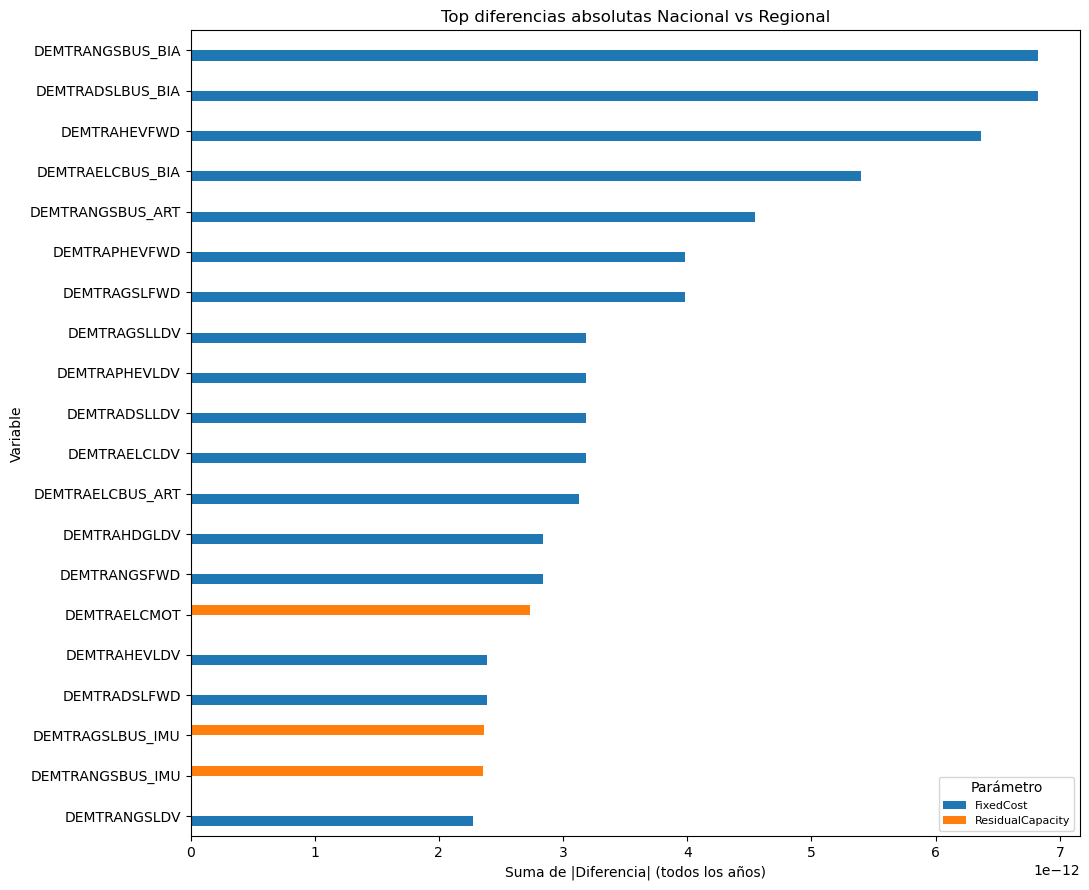

In [23]:
RUTA_PNG = DIR_REPORTES / "top_diferencias.png"

if MODO_COMPARACION != "general":
    display(Markdown(f"**Top-{TOP_N} diferencias absolutas por tecnología/fuel**"))
    display(reporte.top_diferencias(comparacion, n=TOP_N))
    reporte.grafica_top_diferencias(comparacion, n=TOP_N, ruta_png=RUTA_PNG)
else:
    reporte.grafica_discrepancias_por_parametro(discrepancias)

## 5. Exportar reporte

El Excel se escribe **una sola vez en la sección 8** (reporte extendido), que incluye
estas mismas hojas — **Comparacion** (filas sobre el umbral resaltadas en rojo vía
formato condicional), **Anomalias**, **Resumen** — más las adicionales. Exportarlo
también aquí duplicaba minutos de escritura en modo `general`.

In [24]:
# El export del Excel se difiere a la sección 8 para no escribirlo dos veces.
RUTA_REPORTE = DIR_REPORTES / "Reporte_Comparacion_Nacional_vs_Regional.xlsx"
print(f"Export diferido a la sección 8 → {RUTA_REPORTE.name}")
if MODO_COMPARACION != "general":
    print(f"Gráfica : {RUTA_PNG}")

Export diferido a la sección 8 → Reporte_Comparacion_Nacional_vs_Regional.xlsx
Gráfica : C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\top_diferencias.png


## 6. Análisis profundo por sector

Para cada sector activo (TRA, IND, RES, TER, AGF, PWR — detección por `contains()`
sobre `TECHNOLOGY`/`FUEL`): inventario del sector, validación de los parámetros clave
(`comparador.PARAMS_CLAVE_SECTOR`; los vacíos en el SAND se saltan) y desglose
variable × región del parámetro con más datos. En modo `parametro`/`lista_parametros`
solo se validan los parámetros del filtro, para los sectores implícitos en ellos.

In [25]:
# --- 6. Análisis profundo por sector (comparador.analisis_por_sector) ---
parametros_analisis = None if MODO_COMPARACION == "general" else PARAMETROS_FILTRO
ambito = df_nacional if MODO_COMPARACION == "general" \
    else df_nacional[df_nacional["Parameter"].isin(PARAMETROS_FILTRO)]
sectores_activos = comparador.detectar_sectores(ambito)
print(f"Sectores activos: {sectores_activos}")

df_reg_prep = comparador.preparar_regional(df_regional,
                                           list(params_cfg["prefijo_region"].values()))

def _resaltar_discrepancias(df, col_pct="Diferencia_Pct"):
    """Filas en rojo cuando |Diferencia %| supera el umbral configurado."""
    def fila_roja(fila):
        pct = fila.get(col_pct)
        alerta = pd.notna(pct) and abs(pct) > UMBRAL_ALERTA
        return ["background-color: #FFC7CE; color: #9C0006" if alerta else ""] * len(fila)
    return df.style.apply(fila_roja, axis=1).hide(axis="index")

analisis_sectores = {}
for n_sector, sector in enumerate(sectores_activos, start=1):
    display(Markdown(f"### 6.{n_sector} Sector {sector}"))
    res = comparador.analisis_por_sector(
        df_nacional, df_regional, sector, otoole["param"], params_cfg,
        diccionario_tech=MAPEOS["diccionario_tech"],
        diccionario_fuel=MAPEOS["diccionario_fuel"],
        parametros=parametros_analisis, df_reg_prep=df_reg_prep,
    )
    analisis_sectores[sector] = res

    # 6.x.1 Inventario del sector
    display(Markdown(f"**6.{n_sector}.1 Inventario** — {res['filas_nacional']:,} filas "
                     f"Nacional / {res['filas_regional']:,} filas Regional"))
    inv_sector = pd.concat([res["inventario_tech"], res["inventario_fuel"]],
                           ignore_index=True)
    if not inv_sector.empty:
        display(inv_sector.groupby(["Dimension", "Categoria"], as_index=False).size())
    if res["modos_tra"] is not None and not res["modos_tra"].empty:
        display(Markdown("Desglose por modo de transporte:"))
        display(res["modos_tra"])

    # 6.x.2 Validación de parámetros clave (mismas rutas aditiva/intensiva del comparador)
    display(Markdown(f"**6.{n_sector}.2 Validación de parámetros clave**"))
    if res["resumen_validacion"].empty:
        display(Markdown("_Sin datos del sector en los parámetros clave "
                         "(o quedaron fuera del filtro)._"))
    else:
        display(res["resumen_validacion"])
        disc = res["validacion"][~res["validacion"]["Coincide"]]
        if not disc.empty:
            display(Markdown(f"Mayores discrepancias ({len(disc):,} filas en total):"))
            display(_resaltar_discrepancias(disc.head(15)))

    # 6.x.3 Desglose variable × región
    if not res["desglose"].empty:
        display(Markdown(f"**6.{n_sector}.3 Desglose por región** — "
                         f"`{res['parametro_desglose']}`, año {res['anio_desglose']} "
                         "(la columna Advertencia_Renombramiento marca FUELs renombrados)"))
        display(_resaltar_discrepancias(res["desglose"].head(30)))

Sectores activos: ['TRA', 'IND', 'RES', 'TER', 'AGF', 'PWR']


### 6.1 Sector TRA

21:41:07 INFO    comparador: Sector TRA: 3065 filas nac / 7371 filas reg, 4 parámetros clave validados


**6.1.1 Inventario** — 3,065 filas Nacional / 7,371 filas Regional

,Dimension,Categoria,size
0,FUEL,En ambos,21
1,FUEL,Solo Nacional,34
2,FUEL,Solo Regional (base),5
3,TECHNOLOGY,En ambos,63
4,TECHNOLOGY,Solo Nacional,3
5,TECHNOLOGY,Solo Regional (base),14


...

,Dimension,Categoria,size
0,FUEL,En ambos,6
1,FUEL,Solo Nacional,38
2,FUEL,Solo Regional (base),7
3,TECHNOLOGY,En ambos,26
4,TECHNOLOGY,Solo Regional (base),3


**6.6.2 Validación de parámetros clave**

,Sector,Parametro,Tipo,Filas,Filas_OK,Filas_Discrepancia,Pct_Discrepancia,Max_Diferencia_Abs
0,PWR,TotalAnnualMaxCapacity,aditivo,297,0,297,100.000000,"1,360.116144"
1,PWR,TotalTechnologyAnnualActivityLowerLimit,aditivo,858,804,54,6.300000,202.053786
2,PWR,TotalAnnualMaxCapacityInvestment,aditivo,348,67,281,80.700000,78.840000


Mayores discrepancias (632 filas en total):

Parametro,TECHNOLOGY,Año,Valor_Nacional,Valor_Regional,Region,Diferencia,Diferencia_Pct,Coincide
TotalAnnualMaxCapacity,PWRGEO,2022,36.907212,0.000000,SUMA_REGIONES,36.907212,1.000000,False
TotalAnnualMaxCapacity,PWRHYDDAM,2022,1360.116144,0.000000,SUMA_REGIONES,1360.116144,1.000000,False
TotalAnnualMaxCapacity,PWRHYDROR,2022,255.851568,0.000000,SUMA_REGIONES,255.851568,1.000000,False
TotalAnnualMaxCapacity,PWRHYDROR_NDC,2022,155.977056,0.000000,SUMA_REGIONES,155.977056,1.000000,False
TotalAnnualMaxCapacity,PWRNUC,2022,78.850000,0.000000,SUMA_REGIONES,78.850000,1.000000,False
TotalAnnualMaxCapacity,PWRSOLRTP,2022,630.720000,0.000000,SUMA_REGIONES,630.720000,1.000000,False
TotalAnnualMaxCapacity,PWRWNDOFS_FIX,2022,857.779200,0.000000,SUMA_REGIONES,857.779200,1.000000,False
TotalAnnualMaxCapacity,PWRWNDOFS_FLO,2022,681.177600,0.000000,SUMA_REGIONES,681.177600,1.000000,False
TotalAnnualMaxCapacity,PWRWNDONS,2022,1103.760000,0.000000,SUMA_REGIONES,1103.760000,1.000000,False
TotalAnnualMaxCapacity,PWRGEO,2023,36.907212,0.000000,SUMA_REGIONES,36.907212,1.000000,False


## 7. Contextualización de anomalías con archivos de mapeo

Cruza las anomalías `SIN_CORRESPONDENCIA` / `TECHNOLOGY_NO_EN_REGIONAL` /
`FUEL_NO_EN_REGIONAL` contra `Insumos/Mapeo/mapeo_tech_fuel.xlsx` y sugiere una acción:
`cambio_de_nombre` | `no_existe_en_region` | `verificar_creacion` | `sin_info`.

In [26]:
# --- 7. Anomalías contextualizadas (requiere mapeo_tech_fuel.xlsx) ---
anomalias_ctx = None
if MAPEOS["mapeo"] is None:
    display(Markdown("_Sección 7 omitida: no existe `Insumos/Mapeo/mapeo_tech_fuel.xlsx`._"))
elif anomalias.empty:
    display(Markdown("_Sin anomalías que contextualizar._"))
else:
    anomalias_ctx = comparador.contextualizar_anomalias(anomalias, MAPEOS["mapeo"])
    display(Markdown(f"**{len(anomalias_ctx)} anomalías contextualizadas** "
                     f"(de {len(anomalias)} totales; solo los tipos "
                     f"{', '.join(comparador.TIPOS_ANOMALIA_CONTEXTUALIZABLES)}):"))
    display(anomalias_ctx.groupby("ACCION_SUGERIDA", as_index=False).size()
            .sort_values("size", ascending=False))
    display(anomalias_ctx.head(30))

**1 anomalías contextualizadas** (de 400 totales; solo los tipos SIN_CORRESPONDENCIA, TECHNOLOGY_NO_EN_REGIONAL, FUEL_NO_EN_REGIONAL):

,ACCION_SUGERIDA,size
0,verificar_creacion,1


,Parametro,Tecnologia_Fuel,Tipo_Anomalia,Detalle,TIENE_MAPEO,REGIONES_ESPERADAS,NOMBRE_REGIONAL,ACCION_SUGERIDA
0,TotalAnnualMaxCapacity,DEMTRAJETSAFAVI,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, IN, NE, OR, SE, SO",,verificar_creacion


## 8. Exportar reporte extendido

Reexporta el mismo Excel de la sección 5 agregando las hojas **Inventario_Tech_Fuel**
y **Por_Sector** (solo en modo `general`), **Sector_Detalle** (sectores analizados en
la sección 6) y **Anomalias_Contextualizadas** (si existe el mapeo). Las hojas que no
aplican según el modo se omiten con advertencia.

In [27]:
# --- 8. Reporte extendido: hojas adicionales sobre el mismo Excel ---
hojas_extra = {}

if MODO_COMPARACION == "general" and inventario is not None:
    hojas_extra["Inventario_Tech_Fuel"] = pd.concat(
        [inventario["tech"], inventario["fuel"]], ignore_index=True)
    hojas_extra["Por_Sector"] = comparador.tabla_por_sector(analisis_sectores)
else:
    print("Advertencia: hojas Inventario_Tech_Fuel y Por_Sector omitidas "
          f"(MODO_COMPARACION = '{MODO_COMPARACION}', requieren 'general').")

detalle_sectores = [r["resumen_validacion"] for r in analisis_sectores.values()
                    if not r["resumen_validacion"].empty]
if detalle_sectores:
    hojas_extra["Sector_Detalle"] = pd.concat(detalle_sectores, ignore_index=True)
else:
    print("Advertencia: hoja Sector_Detalle omitida (sin sectores con datos).")

if anomalias_ctx is not None and not anomalias_ctx.empty:
    hojas_extra["Anomalias_Contextualizadas"] = anomalias_ctx
else:
    print("Advertencia: hoja Anomalias_Contextualizadas omitida (sin mapeo o sin anomalías).")

ruta_reporte = reporte.exportar_reporte_comparacion(
    RUTA_REPORTE,
    comparacion, anomalias, resultado["resumen"],
    umbral_alerta_pct=UMBRAL_ALERTA,
    hojas_extra=hojas_extra,
)
print(f"Reporte extendido: {ruta_reporte}")
print(f"Hojas extra incluidas: {[h for h, df in hojas_extra.items() if df is not None and not df.empty]}")

Advertencia: hojas Inventario_Tech_Fuel y Por_Sector omitidas (MODO_COMPARACION = 'lista_parametros', requieren 'general').
21:41:10 WARNING reporte: Comparación con 55,766 filas: se exportan las 50,000 con mayor |Diferencia|
21:41:22 INFO    reporte: Reporte de comparación exportado: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\Reporte_Comparacion_Nacional_vs_Regional.xlsx
Reporte extendido: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\Reporte_Comparacion_Nacional_vs_Regional.xlsx
Hojas extra incluidas: ['Sector_Detalle', 'Anomalias_Contextualizadas']


---
*Smoke tests de los módulos: `python tests/test_smoke.py` desde la raíz del proyecto.*